In [1]:
import pandas as pd
import os 

In [2]:
root = r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\模型推論結果"
# 取得所有子資料夾
subfolders = [f for f in os.listdir(root) if os.path.isdir(os.path.join(root, f))]
subfolders = ['S8raw']
print(subfolders)
# subfolders.remove("S8")
# subfolders.remove("S9")
print(subfolders)
all_dfs = []
subfolders = ['S8raw', 'S9raw', 'S8', 'S9']
for folder in subfolders:
    preds_path = os.path.join(root, folder, "pred_results")
    print(preds_path)
    if os.path.exists(preds_path):
        for file_name in os.listdir(preds_path):
            print(file_name)
            file_path = os.path.join(preds_path, file_name)
            try:
                df = pd.read_csv(file_path)
                df["source"] = folder
                all_dfs.append(df)
            except Exception as e:
                print(f"無法讀取 {file_path}，原因：{e}")

# 合併所有 CSV
final_df = pd.concat(all_dfs, ignore_index=True)
final_df["subject_id"] = final_df["name"].str[:2]
# 顯示合併結果
print(f"總共合併 {len(all_dfs)} 個 CSV，資料筆數：{len(final_df)}")
print(final_df.head())

['S8raw']
['S8raw']
D:\IC LAB\Gait analysis\碩論相關\實驗結果\模型推論結果\S8raw\pred_results
pred_results_split8_20250605_050001.csv
pred_results_split8_20250605_050641.csv
pred_results_split8_20250605_051129.csv
pred_results_split8_20250605_051651.csv
pred_results_split8_20250605_052257.csv
pred_results_split8_20250605_052820.csv
pred_results_split8_20250605_053436.csv
pred_results_split8_20250605_053914.csv
pred_results_split8_20250605_054459.csv
pred_results_split8_20250605_055106.csv
pred_results_split8_20250605_055555.csv
pred_results_split8_20250605_060128.csv
pred_results_split8_20250605_060650.csv
pred_results_split8_20250605_061201.csv
pred_results_split8_20250605_061744.csv
pred_results_split8_20250605_062402.csv
pred_results_split8_20250605_062913.csv
pred_results_split8_20250605_063542.csv
pred_results_split8_20250605_064054.csv
pred_results_split8_20250605_064711.csv
pred_results_split8_20250605_065150.csv
pred_results_split8_20250605_065734.csv
pred_results_split8_20250605_070222.csv


In [3]:
print(final_df.columns)

Index(['name', 'pred', 'label', 'source', 'subject_id'], dtype='object')


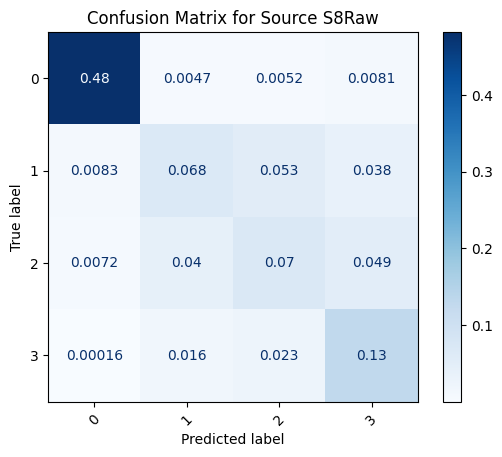

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 篩選出 source 為 S8 的資料
s8_df = final_df[final_df["source"] == "S8raw"]

# 檢查是否包含必要欄位
if "label" not in s8_df.columns or "pred" not in s8_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 計算混淆矩陣
labels = sorted(s8_df["label"].unique())
cm = confusion_matrix(s8_df["label"], s8_df["pred"], labels=labels, normalize='all')

# 畫出混淆矩陣
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix for Source Cluster ST-GCN++")
plt.show()

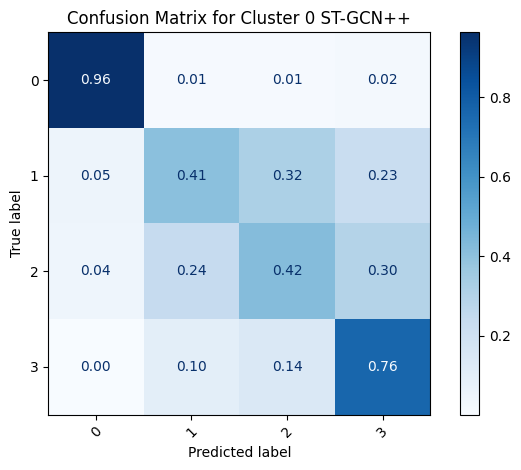

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 篩選出 source 為 S8 的資料
s8_df = final_df[final_df["source"] == "S8raw"]

# 檢查是否包含必要欄位
if "label" not in s8_df.columns or "pred" not in s8_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 取得標籤
labels = sorted(s8_df["label"].unique())

# 計算混淆矩陣（原始數值）
cm = confusion_matrix(s8_df["label"], s8_df["pred"], labels=labels)

# 標準化：將每列除以總和（避免樣本數差異影響）
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# 使用 ConfusionMatrixDisplay 繪圖（維持原樣式）
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45, values_format=".2f")
plt.title("Confusion Matrix for Cluster 0 ST-GCN++")
plt.tight_layout()
plt.show()

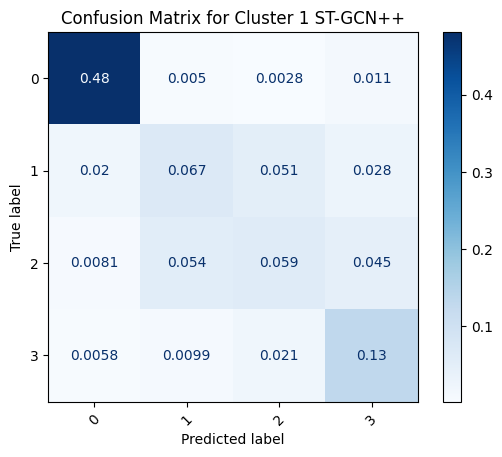

In [11]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 篩選出 source 為 S8 的資料
s8_df = final_df[final_df["source"] == "S9raw"]

# 檢查是否包含必要欄位
if "label" not in s8_df.columns or "pred" not in s8_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 計算混淆矩陣
labels = sorted(s8_df["label"].unique())
cm = confusion_matrix(s8_df["label"], s8_df["pred"], labels=labels, normalize='all')

# 畫出混淆矩陣
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix for Cluster 1 ST-GCN++")
plt.show()

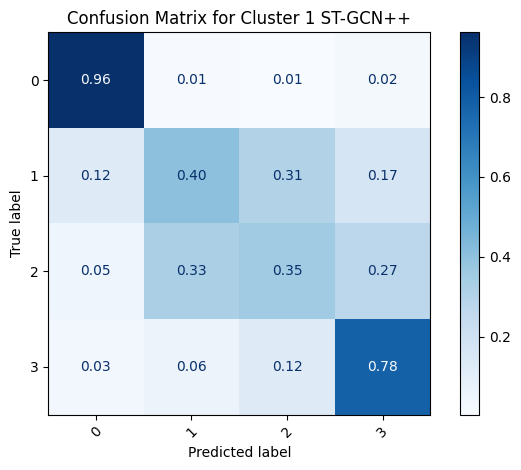

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 篩選出 source 為 S8 的資料
s8_df = final_df[final_df["source"] == "S9raw"]

# 檢查是否包含必要欄位
if "label" not in s8_df.columns or "pred" not in s8_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 取得標籤
labels = sorted(s8_df["label"].unique())

# 計算混淆矩陣（原始數值）
cm = confusion_matrix(s8_df["label"], s8_df["pred"], labels=labels)

# 標準化：將每列除以總和（避免樣本數差異影響）
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# 使用 ConfusionMatrixDisplay 繪圖（維持原樣式）
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45, values_format=".2f")
plt.title("Confusion Matrix for Cluster 1 ST-GCN++")
plt.tight_layout()
plt.show()

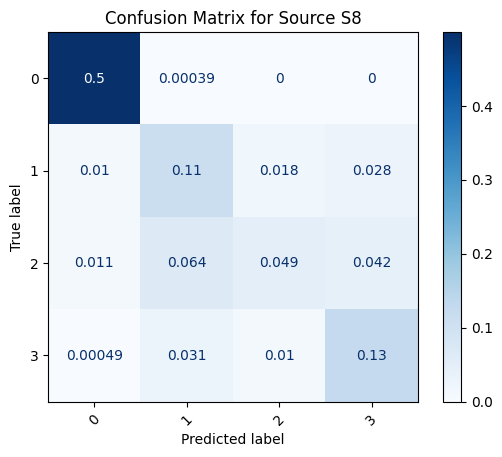

In [6]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 篩選出 source 為 S8 的資料
s8_df = final_df[final_df["source"] == "S8"]

# 檢查是否包含必要欄位
if "label" not in s8_df.columns or "pred" not in s8_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 計算混淆矩陣
labels = sorted(s8_df["label"].unique())
cm = confusion_matrix(s8_df["label"], s8_df["pred"], labels=labels, normalize='all')

# 畫出混淆矩陣
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix for Source S8")
plt.show()

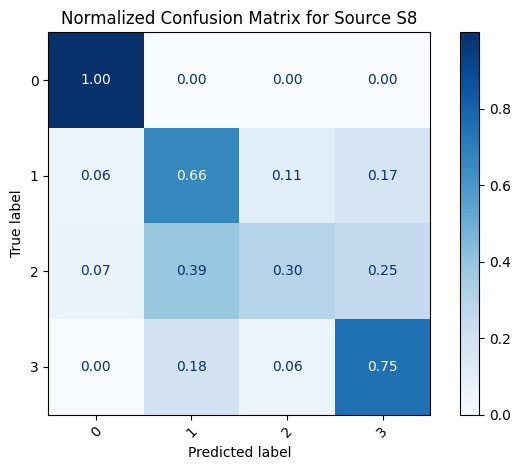

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 篩選出 source 為 S8 的資料
s8_df = final_df[final_df["source"] == "S8"]

# 檢查是否包含必要欄位
if "label" not in s8_df.columns or "pred" not in s8_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 取得標籤
labels = sorted(s8_df["label"].unique())

# 計算混淆矩陣（原始數值）
cm = confusion_matrix(s8_df["label"], s8_df["pred"], labels=labels)

# 標準化：將每列除以總和（避免樣本數差異影響）
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# 使用 ConfusionMatrixDisplay 繪圖（維持原樣式）
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45, values_format=".2f")
plt.title("Normalized Confusion Matrix for Cluster 0 SSO-ST-GCN++")
plt.tight_layout()
plt.show()

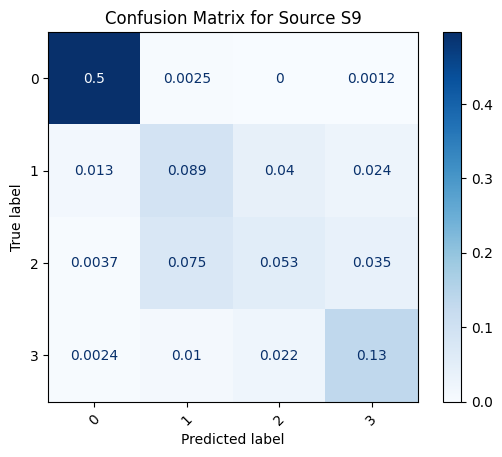

In [7]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 篩選出 source 為 S8 的資料
s9_df = final_df[final_df["source"] == "S9"]

# 檢查是否包含必要欄位
if "label" not in s9_df.columns or "pred" not in s9_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 計算混淆矩陣
labels = sorted(s9_df["label"].unique())
cm = confusion_matrix(s9_df["label"], s9_df["pred"], labels=labels, normalize='all')

# 畫出混淆矩陣
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix for Source S9")
plt.show()

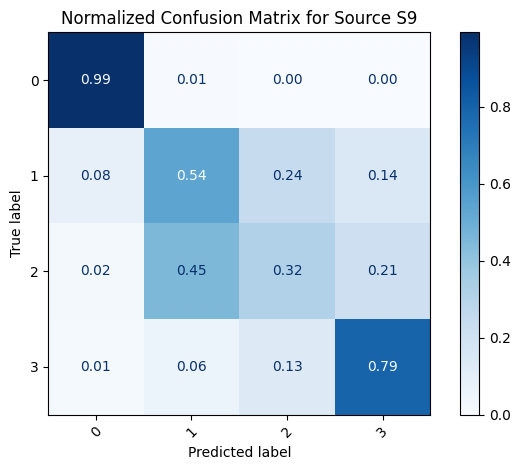

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 篩選出 source 為 S8 的資料
s9_df = final_df[final_df["source"] == "S9"]

# 檢查是否包含必要欄位
if "label" not in s9_df.columns or "pred" not in s9_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 取得標籤
labels = sorted(s9_df["label"].unique())

# 計算混淆矩陣（原始數值）
cm = confusion_matrix(s9_df["label"], s9_df["pred"], labels=labels)

# 標準化：將每列除以總和（避免樣本數差異影響）
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# 使用 ConfusionMatrixDisplay 繪圖（維持原樣式）
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45, values_format=".2f")
plt.title("Normalized Confusion Matrix for Source S9")
plt.tight_layout()
plt.show()

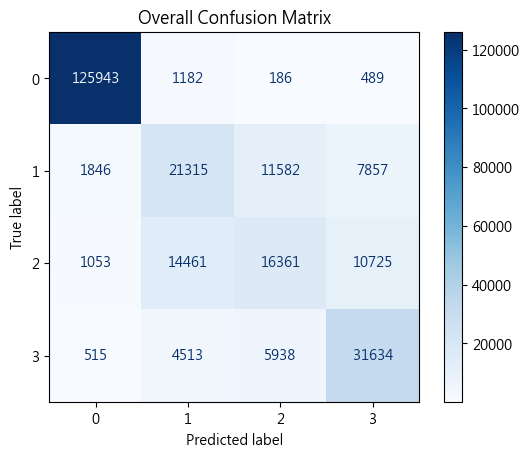

Class 0 - TPR: 0.9855
Class 1 - TPR: 0.5004
Class 2 - TPR: 0.3841
Class 3 - TPR: 0.7426


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 假設欄位名稱為 label 與 preds
cm = confusion_matrix(final_df["label"], final_df["pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Overall Confusion Matrix")
plt.show()

# 每類別的 TPR = 對角線元素 / 該行總和
TPR_per_class = np.diag(cm) / cm.sum(axis=1)

# 顯示每一類的 TPR（可對應類別名稱）
for i, tpr in enumerate(TPR_per_class):
    print(f"Class {i} - TPR: {tpr:.4f}")


In [12]:
import pandas as pd

# 為每筆資料新增一個欄位，表示預測是否正確（1: 正確, 0: 錯誤）
final_df["correct"] = (final_df["pred"] == final_df["label"]).astype(int)

# 依照 name 分組，計算每個 name 的準確率
accuracy_per_name = final_df.groupby("subject_id")["correct"].mean().reset_index()
accuracy_per_name.rename(columns={"correct": "accuracy"}, inplace=True)

# 顯示前幾筆結果
print(accuracy_per_name)

# D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\info.xlsx

   subject_id  accuracy
0          01  0.782222
1          02  0.744444
2          03  0.695000
3          04  0.690278
4          05  0.766667
..        ...       ...
66         67  0.790278
67         68  0.835556
68         69  0.831667
69         70  0.811944
70         71  0.834444

[71 rows x 2 columns]


In [13]:
# 讀入受試者資料
attribute_df = pd.read_excel(r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\info.xlsx")

# 準確率 subject_id → int 編號
accuracy_per_name["受試者編號"] = accuracy_per_name["subject_id"].astype(int)

# 合併受試者資料與準確率
merged_df = pd.merge(attribute_df, accuracy_per_name[["受試者編號", "accuracy"]], on="受試者編號", how="inner")

# 將性別轉換為數值（男=1，女=0）
merged_df["性別"] = merged_df["性別"].map({"男": 1, "女": 0})

# 計算與 accuracy 的相關係數
corr_columns = ["性別", "年齡(歲)", "身高(cm)", "體重(kg)", "BMI", "accuracy"]
corr_matrix = merged_df[corr_columns].corr(method="pearson")

# 顯示與 accuracy 的相關性
print(corr_matrix["accuracy"])


性別         -0.141128
年齡(歲)       0.078382
身高(cm)     -0.135536
體重(kg)     -0.045676
BMI        -0.020743
accuracy    1.000000
Name: accuracy, dtype: float64


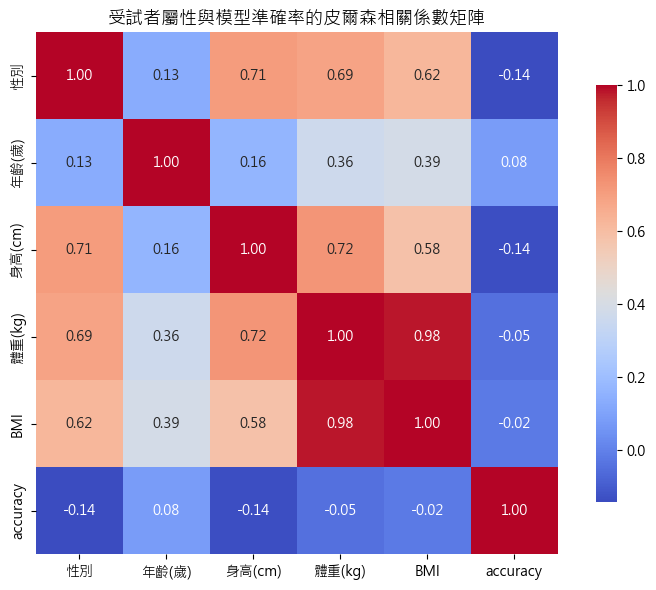

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # 或 'SimHei', 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False
# 繪製熱力圖顯示完整相關係數矩陣（含 accuracy）
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})

plt.title("受試者屬性與模型準確率的皮爾森相關係數矩陣", fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np

# 假設你已經有 final_df（含 'source', 'label', 'pred' 欄位）

# 1. 篩選出 source 為 S8 的資料
s8_df = final_df[final_df["source"] == "S9"]

# 2. 檢查是否包含必要欄位
if "label" not in s8_df.columns or "pred" not in s8_df.columns:
    raise ValueError("資料中必須包含 'label' 和 'pred' 欄位")

# 3. 取得標籤順序（確保一致）
labels = sorted(s8_df["label"].unique())

# 6. 計算各種指標
accuracy = accuracy_score(s8_df["label"], s8_df["pred"])
macro_precision = precision_score(s8_df["label"], s8_df["pred"], labels=labels, average='macro')
macro_recall = recall_score(s8_df["label"], s8_df["pred"], labels=labels, average='macro')
macro_f1 = f1_score(s8_df["label"], s8_df["pred"], labels=labels, average='macro')

# 7. 輸出指標結果
print(f"Accuracy       : {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall   : {macro_recall:.4f}")
print(f"Macro F1-score : {macro_f1:.4f}")

Accuracy       : 0.7707
Macro Precision: 0.6536
Macro Recall   : 0.6597
Macro F1-score : 0.6523
